In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("house_prices.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [10]:
print("Shape :", df.shape)

print("\nColumns\n")
print(df.columns)

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Shape : (21613, 21)

Columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

Missing Values

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Duplicate Rows : 0


In [11]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing numerical values
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Cleaning Completed Successfully!")

Cleaning Completed Successfully!


In [12]:
df.to_csv("cleaned_house_prices.csv", index=False)

In [13]:
report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

report

,Column,Data Type,Missing Values,Unique Values
0,id,int64,0,21436
1,date,object,0,372
2,price,float64,0,4028
3,bedrooms,int64,0,13
4,bathrooms,float64,0,30
5,sqft_living,int64,0,1038
6,sqft_lot,int64,0,9782
7,floors,float64,0,6
8,waterfront,object,0,2
9,view,int64,0,5


In [14]:
report.to_csv("data_quality_report.csv", index=False)

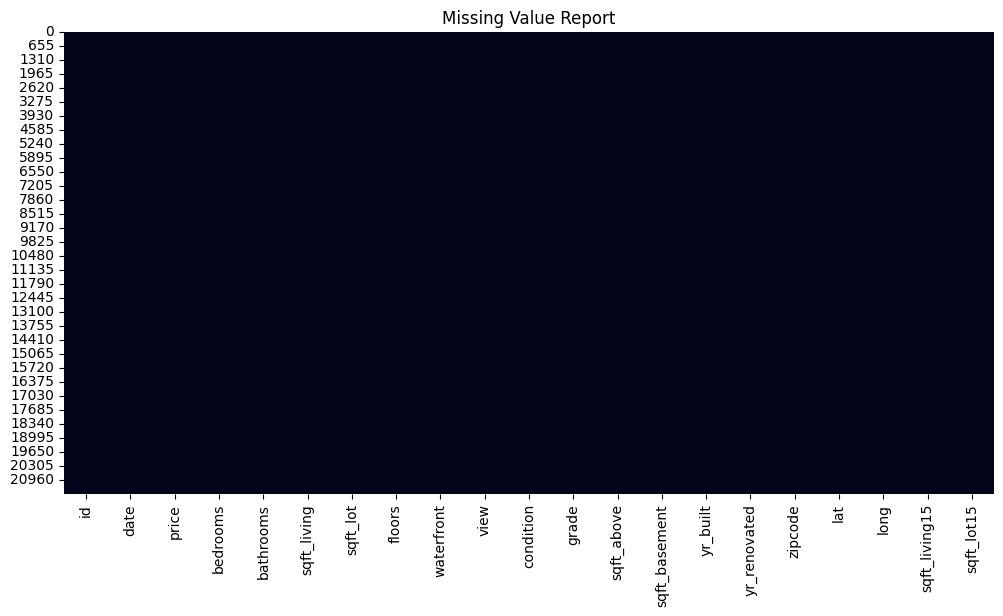

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Report")

plt.savefig("missing_values_report.png", dpi=300)

plt.show()

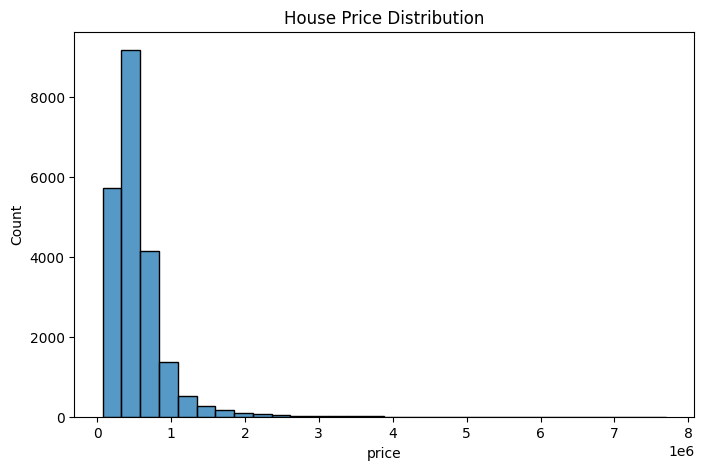

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30)

plt.title("House Price Distribution")

plt.savefig("price_distribution.png", dpi=300)

plt.show()

In [17]:
print("="*50)
print("DATA CLEANING REPORT")
print("="*50)

print("Original Shape :", df.shape)
print("Duplicate Rows :", df.duplicated().sum())
print("Missing Values :", df.isnull().sum().sum())

print("\nReport Generated Successfully!")

print("="*50)

DATA CLEANING REPORT
Original Shape : (21613, 21)
Duplicate Rows : 0
Missing Values : 0

Report Generated Successfully!
